# A split test measures a transfer between the arms; the decision needs the total

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/interference-check/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/interference-check/demo.ipynb)

**Day 168 - `interference-check` - Data Science Cookbook**

A randomised A/B test estimates the difference between a treated unit and a control unit
*in a world where half of everybody is treated*. The decision it gets used for is the
difference between **everybody** treated and **everybody** control. Those two quantities
are the same number only if one unit's assignment cannot touch another unit's outcome -
the "no interference" half of SUTVA. It is the assumption nobody writes down, and it is
false in every marketplace, every shared budget, every social feature and every shared
model.

This notebook builds two worlds where it is false **in opposite directions**, then tries
the three designs usually offered as the fix.

Contents:

1. One market, one clean test, and a number that is 97% bias
2. The bias is a cliff, and its edge is between utilisation 1.3 and 1.2
3. Negative result: more traffic makes it worse, not better
4. Negative result: the same estimator fails in both directions and cannot say which
5. Negative result: the recommended guard test is ~100x less sensitive than the test it guards
6. Cluster randomisation works if - and only if - the cluster contains the mechanism
7. Switchback: the balanced design is exactly twice as biased as coin-flipping
8. What to put in the test plan

Everything below is measured. The ground truth in each world is a *second* simulation of
the same world under global treatment and global control - which is precisely the quantity
a real experiment can never observe, and the only reason the bias is knowable here.

## 1. The world, and the estimator

A marketplace with 20,000 buyers a day and 2,000 things to sell. Control buyers try to buy
at 10%; treated buyers try at 13%. The feature **works** - it genuinely makes people want
to buy more. Attempts are served while supply lasts, and when attempts exceed supply the
served set is a uniform random subset.

Two functions is the whole engine: one that plays out a day given who is treated, and one
that runs a conventional user-level split inside it.

In [1]:
from __future__ import annotations

import numpy as np

PC, PT = 0.10, 0.13          # control / treated attempt rate
N, SUPPLY = 20_000, 2_000    # buyers per day, things to sell


def rationed_outcomes(z, p_control, p_treat, supply, rng, group=None, supply_per_group=None):
    """One day of the market.  z is the 0/1 assignment vector; returns 0/1 purchases."""
    p = np.where(z == 1, p_treat, p_control)
    attempt = rng.random(z.size) < p
    y = np.zeros(z.size)
    if group is None or supply_per_group is None:
        idx = np.flatnonzero(attempt)
        if idx.size == 0:
            return y
        if idx.size <= supply:
            y[idx] = 1.0
        else:
            y[rng.choice(idx, size=supply, replace=False)] = 1.0
        return y
    for g in np.unique(group):
        idx = np.flatnonzero(attempt & (group == g))
        if idx.size <= supply_per_group:
            y[idx] = 1.0
        else:
            y[rng.choice(idx, size=supply_per_group, replace=False)] = 1.0
    return y


def split_estimate(n, p_c, p_t, supply, rng, share_treated=0.5):
    """A conventional user-level A/B test, with the SE the test would report."""
    z = np.zeros(n, dtype=int)
    z[rng.choice(n, size=int(round(n * share_treated)), replace=False)] = 1
    y = rationed_outcomes(z, p_c, p_t, supply, rng)
    yt, yc = y[z == 1], y[z == 0]
    se = np.sqrt(yt.var(ddof=1) / yt.size + yc.var(ddof=1) / yc.size)
    return yt.mean() - yc.mean(), se


def global_effect(n, p_c, p_t, supply, rng, reps=120):
    """The counterfactual an experiment cannot run: everybody treated vs everybody control."""
    ones, zeros = np.ones(n, dtype=int), np.zeros(n, dtype=int)
    t = np.mean([rationed_outcomes(ones, p_c, p_t, supply, rng).mean() for _ in range(reps)])
    c = np.mean([rationed_outcomes(zeros, p_c, p_t, supply, rng).mean() for _ in range(reps)])
    return t - c


rng = np.random.default_rng(168)
print(f"utilisation: {SUPPLY / (N * PC):.2f} units of supply per expected attempt")

utilisation: 1.00 units of supply per expected attempt


### Run the test, then run the counterfactual

The test is textbook: random assignment, no peeking, no sample-ratio mismatch, plenty of
traffic. Nothing about the procedure is wrong.

In [2]:
runs = [split_estimate(N, PC, PT, SUPPLY, rng) for _ in range(200)]
est = np.array([e for e, _ in runs])
ses = np.array([s for _, s in runs])
truth = global_effect(N, PC, PT, SUPPLY, rng)

print("WHAT THE A/B TEST REPORTS")
print(f"  estimate        {est.mean():+.5f}   ({100 * est.mean() / PC:+.1f}% on a {PC:.0%} base)")
print(f"  reported SE      {ses.mean():.5f}")
print(f"  p < 0.05 in     {np.mean(np.abs(est / ses) > 1.96):.1%} of runs")
print()
print("WHAT SHIPPING IT TO EVERYBODY ACTUALLY DOES")
print(f"  global effect   {truth:+.5f}")
print(f"  bias            {est.mean() - truth:+.5f}  = {100 * (est.mean() - truth) / est.mean():.0f}% of the reported number")

WHAT THE A/B TEST REPORTS
  estimate        +0.02569   (+25.7% on a 10% base)
  reported SE      0.00424
  p < 0.05 in     100.0% of runs

WHAT SHIPPING IT TO EVERYBODY ACTUALLY DOES
  global effect   +0.00079
  bias            +0.02490  = 97% of the reported number


The test is not broken. It measured, correctly, the difference between a treated buyer and
a control buyer *in a market where half of everybody is treated*. In that market the
treated buyers win the scarce supply off the control buyers, and the estimate is that
**transfer**. Treat everybody and there is nobody left to take it from.

Note what the reported SE is doing: it is small, the p-value is tiny, and both are telling
the truth about a quantity nobody wanted.

## 2. The bias is a cliff, not a gradient

Both quantities have closed forms, which is what makes this diagnosable in advance rather
than only in hindsight:

- **truth** = `min(p_t, S/n) - min(p_c, S/n)` - the whole market is capped by supply
- **split estimate** = `(p_t - p_c) x min(1, S / (n x mean attempt rate))` - both arms face
  the *same* rationing factor, so it multiplies the difference and cancels out of it

That second formula is the reason the readout cannot warn you: the rationing shows up
identically in both arms.

In [3]:
print(f"{'supply':>7} {'util':>6} {'split':>8} {'truth':>8} {'overstates':>11}  {'cf split':>9} {'cf truth':>9}")
sweep = []
for supply in (4000, 3000, 2600, 2400, 2200, 2000, 1800, 1400):
    e = np.mean([split_estimate(N, PC, PT, supply, rng)[0] for _ in range(120)])
    t = global_effect(N, PC, PT, supply, rng, reps=80)
    cf_t = min(PT, supply / N) - min(PC, supply / N)
    cf_e = (PT - PC) * min(1.0, supply / (N * (PT + PC) / 2))
    over = f"{100 * (e - t) / t:>10.0f}%" if t > 1e-9 else f"{'infinite':>11}"
    sweep.append((supply / (N * PC), e, t))
    print(f"{supply:>7} {supply / (N * PC):>6.2f} {e:>8.5f} {t:>8.5f} {over}  {cf_e:>9.5f} {cf_t:>9.5f}")

 supply   util    split    truth  overstates   cf split  cf truth
   4000   2.00  0.02999  0.02974          1%    0.03000   0.03000
   3000   1.50  0.02960  0.02960          0%    0.03000   0.03000
   2600   1.30  0.02994  0.02890          4%    0.03000   0.03000
   2400   1.20  0.02943  0.02002         47%    0.03000   0.02000
   2200   1.10  0.02890  0.01025        182%    0.02870   0.01000
   2000   1.00  0.02597  0.00068       3718%    0.02609   0.00000
   1800   0.90  0.02393  0.00000    infinite    0.02348   0.00000
   1400   0.70  0.01815  0.00000    infinite    0.01826   0.00000


Read the `overstates` column downwards. At utilisation 1.30 the split overstates by ~3%.
At 1.20 it overstates by ~52%. At 1.00 the entire reported number is bias.

**No dashboard distinguishes 1.30 from 1.20.** Utilisation during the test window is not
nice-to-have context for an experiment in a constrained market - it is the parameter that
decides whether the readout means anything, and it belongs on the test plan.

## 3. Negative result: more traffic makes it worse

The instinct when a result looks too good is to re-run it bigger. Scale the market and the
supply together, so utilisation stays at 1.00 and the world is the same world - only bigger.

In [4]:
print(f"{'n':>8} {'truth':>8} {'split':>8} {'bias':>8} {'SE':>8} {'95% cover':>10} {'p<.05':>7}")
rows = []
for k in (1, 2, 4, 8, 16):
    n = 12_500 * k
    supply = int(n * PC)
    t = global_effect(n, PC, PT, supply, rng, reps=max(20, 120 // k))
    e, s = [], []
    for _ in range(120):
        a, b = split_estimate(n, PC, PT, supply, rng)
        e.append(a); s.append(b)
    e, s = np.array(e), np.array(s)
    cover = np.mean((e - 1.96 * s <= t) & (t <= e + 1.96 * s))
    power = np.mean(np.abs(e / s) > 1.96)
    rows.append({"n": n, "bias": e.mean() - t, "se": s.mean(), "cover": cover})
    print(f"{n:>8,} {t:>8.5f} {e.mean():>8.5f} {e.mean() - t:>8.5f} {s.mean():>8.5f} {cover:>10.3f} {power:>7.3f}")

print(f"\nbias  {rows[0]['bias']:.5f} -> {rows[-1]['bias']:.5f}   (flat)")
print(f"SE    {rows[0]['se']:.5f} -> {rows[-1]['se']:.5f}   ({rows[0]['se'] / rows[-1]['se']:.1f}x smaller)")

       n    truth    split     bias       SE  95% cover   p<.05
  12,500  0.00094  0.02592  0.02498  0.00536      0.000   1.000
  25,000  0.00079  0.02583  0.02504  0.00379      0.000   1.000
  50,000  0.00046  0.02595  0.02548  0.00268      0.000   1.000
 100,000  0.00014  0.02584  0.02570  0.00190      0.000   1.000
 200,000  0.00027  0.02603  0.02575  0.00134      0.000   1.000

bias  0.02498 -> 0.02575   (flat)
SE    0.00536 -> 0.00134   (4.0x smaller)


The bias is flat across the whole range; the standard error falls by ~4x; coverage of the
true global effect goes to zero and stays there; and the experiment's own power is ~1.000
the entire way.

*n* is in the variance and it is not in the bias. A confident, tight, highly significant
interval around the wrong number is the **expected** output of doing this carefully. This
is the same shape the [`diff-in-diff`](../diff-in-diff/) build found for a parallel-trends
violation, and it has the same cause.

## 4. Negative result: the same estimator fails in both directions

A different world. 300 peer groups of 20. The feature moves a user by `tau = 1.0` directly,
and by `gamma = 0.5` more when *all* of their peers have it too - a referral loop, a shared
feed, a network good. The true global effect is `tau + gamma = 1.5`.

Under a within-group 50/50 split, a treated user has `(m/2 - 1)` of their `(m-1)` peers
treated and a control user has `m/2`. The difference is `-1/(m-1)`, so the split recovers
the **direct** effect and misses the indirect one entirely - then overshoots by one peer's
worth in the other direction. Bias `= -gamma x m/(m-1)`, exactly, with no *n* in it.

In [5]:
def spillover_outcomes(z, group, tau, gamma, sigma, rng, group_sd=0.0):
    """Linear-in-means peer effects.  group_sd is a per-group intercept."""
    y = rng.normal(0.0, sigma, z.size)
    if group_sd > 0:
        eff = {g: v for g, v in zip(np.unique(group).tolist(), rng.normal(0.0, group_sd, np.unique(group).size))}
        y = y + np.array([eff[g] for g in group.tolist()])
    for g in np.unique(group):
        idx = np.flatnonzero(group == g)
        m = idx.size
        y[idx] += tau * z[idx] + gamma * (z[idx].sum() - z[idx]) / (m - 1)
    return y


def assign_within_group(group, rng):
    z = np.zeros(group.size, dtype=int)
    for g in np.unique(group):
        idx = np.flatnonzero(group == g)
        z[rng.choice(idx, size=idx.size // 2, replace=False)] = 1
    return z


def assign_by_group(group, rng):
    gs = np.unique(group)
    treated = set(rng.choice(gs, size=gs.size // 2, replace=False).tolist())
    return np.array([1 if g in treated else 0 for g in group.tolist()], dtype=int)


def user_estimate(y, z):
    return y[z == 1].mean() - y[z == 0].mean()


def cluster_estimate(y, z, group):
    gs = np.unique(group)
    means = np.array([y[group == g].mean() for g in gs])
    zs = np.array([z[group == g][0] for g in gs])
    return means[zs == 1].mean() - means[zs == 0].mean()


M, GROUPS, TAU, GAMMA = 20, 300, 1.0, 0.5
group = np.repeat(np.arange(GROUPS), M)
peer_truth = TAU + GAMMA

split_peer = np.mean([
    user_estimate(spillover_outcomes((z := assign_within_group(group, rng)), group, TAU, GAMMA, 1.0, rng), z)
    for _ in range(200)
])
bias_cf = -GAMMA * M / (M - 1)

print(f"  split estimate    {split_peer:.4f}   closed form {TAU - GAMMA / (M - 1):.4f}")
print(f"  true global       {peer_truth:.4f}")
print(f"  bias              {split_peer - peer_truth:.4f}   closed form {bias_cf:.4f}")
print(f"  effect missed     {100 * abs(bias_cf) / peer_truth:.1f}%")
print()
print(f"  MARKETPLACE world: split OVERSTATES - {100 * (est.mean() - truth) / est.mean():.0f}% of the reported number is bias")
print(f"  PEER world:        split UNDERSTATES - it misses {100 * abs(bias_cf) / peer_truth:.0f}% of the real effect")

  split estimate    0.9743   closed form 0.9737
  true global       1.5000
  bias              -0.5257   closed form -0.5263
  effect missed     35.1%

  MARKETPLACE world: split OVERSTATES - 97% of the reported number is bias
  PEER world:        split UNDERSTATES - it misses 35% of the real effect


Same randomisation, same estimator, same clean p-value, **opposite** error - and nothing in
the output distinguishes the two cases. Which way you are wrong is a fact about the
mechanism, and you have to argue it *before* the test rather than read it *after*.

This is the practical consequence: "we might have interference" is not a caveat you can add
to a result. It changes the sign.

## 5. Negative result: the recommended guard test is nearly blind

The standard defence is a **dose-response design**: run the feature at two treated shares
(say 10% and 50%) and test whether the estimated effect depends on the share. Under no
interference it cannot; under interference it must. The logic is correct. The power is the
problem.

In [6]:
from scipy import stats


def dose_response_check(n, p_c, p_t, supply, rng, shares=(0.1, 0.5)):
    e1, s1 = split_estimate(n, p_c, p_t, supply, rng, share_treated=shares[0])
    e2, s2 = split_estimate(n, p_c, p_t, supply, rng, share_treated=shares[1])
    diff = e1 - e2
    se = np.sqrt(s1 ** 2 + s2 ** 2)
    return 2 * (1 - stats.norm.cdf(abs(diff / se)))


# calibration: a market with unlimited supply, so no interference at all
p_null = np.array([dose_response_check(N, PC, PT, 10 ** 9, rng) for _ in range(300)])
print(f"false-alarm rate under NO interference: {np.mean(p_null < 0.05):.3f}   (nominal 0.05 - honest)")
print()
print(f"{'n':>10} {'power':>7}")
chk = []
for n in (20_000, 100_000, 400_000):
    p = np.array([dose_response_check(n, PC, PT, int(n * PC), rng) for _ in range(150)])
    chk.append((n, np.mean(p < 0.05)))
    print(f"{n:>10,} {np.mean(p < 0.05):>7.3f}")

# the check's non-centrality grows as sqrt(n), so extrapolate what 0.80 would take
lam = 1.96 + stats.norm.ppf(min(max(chk[-1][1], 1e-6), 1 - 1e-6))
need = chk[-1][0] * ((1.96 + stats.norm.ppf(0.80)) / lam) ** 2
print(f"\nextrapolated n for power 0.80: {need / 1e6:.2f}M  ({need / 12_500:.0f}x the n at which")
print("the experiment itself is already at power 1.000)")

false-alarm rate under NO interference: 0.053   (nominal 0.05 - honest)

         n   power
    20,000   0.067
   100,000   0.133
   400,000   0.307

extrapolated n for power 0.80: 1.48M  (119x the n at which
the experiment itself is already at power 1.000)


The check is calibrated - it false-alarms at its nominal rate. It is also, at the traffic
you actually have, very nearly a coin that says *no*.

Compare the [`srm-detector`](../srm-detector/) build, where the guard test was **6x more
sensitive** than the experiment it protected and still was not protective. A guard test
being valid tells you nothing about whether it guards. Passing this one is not evidence of
no interference; it is evidence that you ran it.

## 6. Cluster randomisation works if - and only if - the cluster contains the mechanism

Randomise whole cities instead of individual buyers, and buyers in a treated city compete
only with other treated buyers. That is a real fix. Here are two versions of the *same*
market: in one, each city has its own supply; in the other, the identical total supply sits
in one national pool.

**Nothing a data team can see distinguishes them.** Same rows, same volumes, same
conversion rate.

In [7]:
GROUPS_C, PER_CITY = 40, 500
city = np.repeat(np.arange(GROUPS_C), PER_CITY)
n_c = city.size
local_supply = int(PER_CITY * PC)          # utilisation 1.00 in each city
national_supply = local_supply * GROUPS_C  # the identical total, pooled

for contained in (True, False):
    def day(z):
        if contained:
            return rationed_outcomes(z, PC, PT, 0, rng, group=city, supply_per_group=local_supply)
        return rationed_outcomes(z, PC, PT, national_supply, rng)

    t = np.mean([day(np.ones(n_c, dtype=int)).mean() for _ in range(30)]) - \
        np.mean([day(np.zeros(n_c, dtype=int)).mean() for _ in range(30)])
    sp = np.mean([user_estimate(day(z := assign_within_group(city, rng)), z) for _ in range(80)])
    cl = np.mean([cluster_estimate(day(z := assign_by_group(city, rng)), z, city) for _ in range(80)])
    removed = 100 * (1 - abs(cl - t) / abs(sp - t))
    label = "supply LOCAL to each city" if contained else "supply POOLED nationally"
    print(f"{label}")
    print(f"   true global effect  {t:+.5f}")
    print(f"   user-level split    {sp:+.5f}   bias {sp - t:+.5f}")
    print(f"   cluster randomised  {cl:+.5f}   bias {cl - t:+.5f}")
    print(f"   -> clustering removed {removed:.0f}% of the bias\n")

supply LOCAL to each city
   true global effect  +0.00527
   user-level split    +0.02559   bias +0.02032
   cluster randomised  +0.00529   bias +0.00001
   -> clustering removed 100% of the bias

supply POOLED nationally
   true global effect  +0.00072
   user-level split    +0.02540   bias +0.02468
   cluster randomised  +0.02645   bias +0.02574
   -> clustering removed -4% of the bias



Cluster randomisation is not a fix for interference. It is a fix for interference **that
stops at the cluster edge**, and where that edge is is a claim about the supply chain, not
about the schema. Randomising cities against a national pool still leaves treated cities
taking supply off control cities, and removes 0% of the bias while paying the full design
effect.

That design effect, incidentally, is larger than the textbook says. `1 + (m-1) x ICC`
compares cluster assignment to *simple* random assignment - but a within-group 50/50 split
is not simple random assignment, it is **stratified** by the cluster, so it cancels the
between-group variance exactly rather than in expectation. Against that baseline the right
expression is `1 + m x (sd_group / sd_user)^2`, which at m=20 and ICC 0.168 is 5.05 rather
than 4.20. `evidence.py` section 7 measures both.

## 7. Switchback: the balanced design is exactly twice as biased

Randomise **time** instead of users: the whole market is treated for a period, then
control. Interference inside a period is no longer between arms, so a shared pool stops
being a problem. The failure mode is that the system does not switch instantly - if a
fraction `c` of each period is still behaving like the previous one, the arms bleed.

In [8]:
def switchback_run(n_periods, tau, carryover, sigma, rng, alternating=False, burn_in=0.0):
    z = (np.arange(n_periods) % 2) if alternating else (rng.random(n_periods) < 0.5).astype(int)
    z_prev = np.concatenate(([z[0]], z[:-1]))
    keep = 1.0 - burn_in
    residual = max(0.0, carryover - burn_in) / keep
    w = (1.0 - residual) * z + residual * z_prev
    y = tau * w + rng.normal(0.0, sigma / np.sqrt(keep), n_periods)
    return y[z == 1].mean() - y[z == 0].mean()


print(f"{'carryover':>10} {'coin-flip':>22} {'strict ABAB':>22}")
sb = []
for c in (0.0, 0.05, 0.10, 0.20, 0.30):
    coin = np.mean([switchback_run(400, 1.0, c, 1.0, rng) for _ in range(300)])
    abab = np.mean([switchback_run(400, 1.0, c, 1.0, rng, alternating=True) for _ in range(300)])
    sb.append((c, coin, abab))
    print(f"{c:>10.2f} {coin:>13.4f} / {1 - c:<6.3f} {abab:>13.4f} / {1 - 2 * c:<6.3f}")

print("\n(measured / closed form)  coin-flip attenuates by c;  strict ABAB by 2c")
print("\nburn-in against a TRUE carryover of 0.20:")
print(f"{'burn-in':>8} {'E[est]':>8} {'bias^2':>9} {'var':>9} {'MSE':>9}")
for b in (0.0, 0.10, 0.20, 0.45):
    e = np.array([switchback_run(400, 1.0, 0.20, 1.0, rng, burn_in=b) for _ in range(400)])
    print(f"{b:>8.2f} {e.mean():>8.4f} {(e.mean() - 1) ** 2:>9.5f} {e.var():>9.5f} {(e.mean() - 1) ** 2 + e.var():>9.5f}")

 carryover              coin-flip            strict ABAB
      0.00        0.9961 / 1.000         1.0028 / 1.000 
      0.05        0.9530 / 0.950         0.9053 / 0.900 
      0.10        0.9083 / 0.900         0.8102 / 0.800 
      0.20        0.7952 / 0.800         0.6011 / 0.600 
      0.30        0.6972 / 0.700         0.4066 / 0.400 

(measured / closed form)  coin-flip attenuates by c;  strict ABAB by 2c

burn-in against a TRUE carryover of 0.20:
 burn-in   E[est]    bias^2       var       MSE
    0.00   0.7990   0.04040   0.01001   0.05041
    0.10   0.8814   0.01406   0.01082   0.02488
    0.20   0.9997   0.00000   0.01298   0.01298
    0.45   1.0082   0.00007   0.01427   0.01433


A treated period's predecessor under strict alternation is *always* a control period, so
the contamination pushes both arms the wrong way instead of one. The tidy, obviously-fairer
ABAB schedule is exactly twice as biased as flipping a coin.

Burn-in fixes it, and the optimum is not a preference: discard less than the carryover and
bias survives at any sample size; discard more and you pay `1/(1-b)` of the variance for
nothing. Minimum MSE sits at burn-in = the true carryover - which makes the settling time a
**measurement** somebody has to take. If nobody has, the switchback has an unknown
attenuation and its result is a lower bound on the effect. That is at least an honest thing
to write down.

Note also: periods, not users, are the sample here. 400 periods is n=400.

## The picture

Four of the results above, on one page.

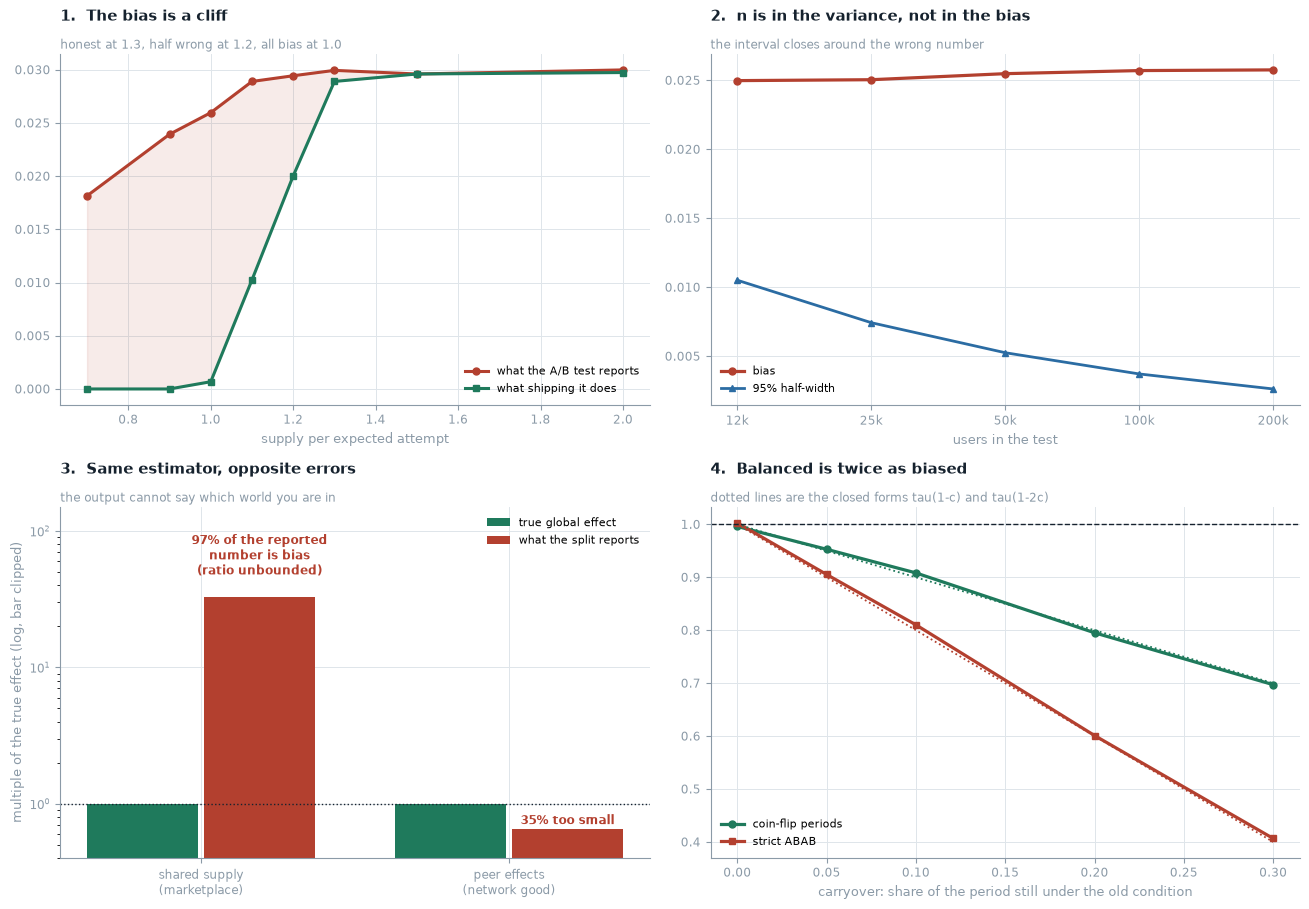

In [9]:
import matplotlib.pyplot as plt

INK, MUTE, GOOD, BAD, WARN, COOL, GRID = "#16222e", "#8b9aa7", "#1f7a5c", "#b3402f", "#c98a1a", "#2b6ca3", "#dfe5ea"
fig, ax = plt.subplots(2, 2, figsize=(13.2, 9.2))
fig.patch.set_facecolor("white")


def style(a, title, sub=""):
    a.set_title(title, fontsize=11, fontweight="bold", color=INK, loc="left", pad=24)
    if sub:
        a.text(0, 1.015, sub, transform=a.transAxes, fontsize=8.3, color=MUTE)
    a.grid(True, color=GRID, lw=0.7); a.set_axisbelow(True)
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        a.spines[s].set_color(MUTE)
    a.tick_params(colors=MUTE, labelsize=8.4)


u = [s[0] for s in sweep][::-1]; sp_c = [s[1] for s in sweep][::-1]; tr_c = [s[2] for s in sweep][::-1]
ax[0][0].plot(u, sp_c, "o-", color=BAD, lw=2.2, ms=5, label="what the A/B test reports")
ax[0][0].plot(u, tr_c, "s-", color=GOOD, lw=2.2, ms=5, label="what shipping it does")
ax[0][0].fill_between(u, tr_c, sp_c, color=BAD, alpha=0.10)
ax[0][0].set_xlabel("supply per expected attempt", fontsize=9, color=MUTE)
ax[0][0].legend(fontsize=8.2, frameon=False, loc="lower right")
style(ax[0][0], "1.  The bias is a cliff", "honest at 1.3, half wrong at 1.2, all bias at 1.0")

nn = [r["n"] for r in rows]
ax[0][1].plot(nn, [r["bias"] for r in rows], "o-", color=BAD, lw=2.3, ms=5, label="bias")
ax[0][1].plot(nn, [1.96 * r["se"] for r in rows], "^-", color=COOL, lw=2.0, ms=5, label="95% half-width")
ax[0][1].set_xscale("log"); ax[0][1].set_xticks(nn)
ax[0][1].set_xticklabels([f"{v // 1000}k" for v in nn]); ax[0][1].minorticks_off()
ax[0][1].set_xlabel("users in the test", fontsize=9, color=MUTE)
ax[0][1].legend(fontsize=8.2, frameon=False)
style(ax[0][1], "2.  n is in the variance, not in the bias", "the interval closes around the wrong number")

CAP = 40.0
rel = [est.mean() / max(truth, 1e-9), split_peer / peer_truth]
ax[1][0].bar([-0.19, 0.81], [1, 1], 0.36, color=GOOD, label="true global effect")
ax[1][0].bar([0.19, 1.19], [min(rel[0], CAP), rel[1]], 0.36, color=BAD, label="what the split reports")
ax[1][0].axhline(1.0, color=INK, lw=1.0, ls=":")
ax[1][0].set_yscale("log"); ax[1][0].set_ylim(0.4, 150)
ax[1][0].set_xticks([0, 1]); ax[1][0].set_xticklabels(["shared supply\n(marketplace)", "peer effects\n(network good)"], fontsize=8.6, color=INK)
# the marketplace ratio is unbounded (its truth is ~0), so quote the stable number
ax[1][0].text(0.19, CAP * 1.2, f"{100 * (est.mean() - truth) / est.mean():.0f}% of the reported\nnumber is bias\n(ratio unbounded)", ha="center", fontsize=8.3, color=BAD, fontweight="bold")
ax[1][0].text(1.19, rel[1] * 1.09, f"{100 * (1 - rel[1]):.0f}% too small", ha="center", fontsize=8.8, color=BAD, fontweight="bold")
ax[1][0].set_ylabel("multiple of the true effect (log, bar clipped)", fontsize=9, color=MUTE)
ax[1][0].legend(fontsize=8.2, frameon=False, loc="upper right")
style(ax[1][0], "3.  Same estimator, opposite errors", "the output cannot say which world you are in")

c_ax = [s[0] for s in sb]
ax[1][1].plot(c_ax, [s[1] for s in sb], "o-", color=GOOD, lw=2.3, ms=5, label="coin-flip periods")
ax[1][1].plot(c_ax, [s[2] for s in sb], "s-", color=BAD, lw=2.3, ms=5, label="strict ABAB")
ax[1][1].plot(c_ax, [1 - c for c in c_ax], ":", color=GOOD, lw=1.3)
ax[1][1].plot(c_ax, [1 - 2 * c for c in c_ax], ":", color=BAD, lw=1.3)
ax[1][1].axhline(1.0, color=INK, lw=1.0, ls="--")
ax[1][1].set_xlabel("carryover: share of the period still under the old condition", fontsize=9, color=MUTE)
ax[1][1].legend(fontsize=8.2, frameon=False, loc="lower left")
style(ax[1][1], "4.  Balanced is twice as biased", "dotted lines are the closed forms tau(1-c) and tau(1-2c)")

fig.tight_layout()
fig.savefig("interference_notebook_figure.png", dpi=150, facecolor="white")
plt.show()

## 8. What to put in the test plan

| # | Report this | Because |
|---|-------------|---------|
| 1 | The interference **mechanism** you are ruling out, named before the test - shared supply, shared budget, shared model, peers, or none | It decides the **sign** of your error, and no output can recover it (sections 1 and 4) |
| 2 | For a constrained market: **utilisation** during the test window | 1.3 overstates by ~3%, 1.2 by ~52%, 1.0 by ~infinity (section 2) |
| 3 | Never "we will re-run it bigger to be sure" | Bias is flat in *n* and coverage goes to 0.000 (section 3) |
| 4 | If you ran a dose-response check: its **power**, not its p-value | At experiment-sized traffic it fires ~0.07 on a market that is 97% bias (section 5) |
| 5 | If you clustered: what the cluster is a boundary **of**, and why it contains the mechanism | The wrong level removes 0% of the bias and pays the whole design effect (section 6) |
| 6 | If you switchbacked: the measured settling time and the burn-in | Coin-flip attenuates by `c`, ABAB by `2c` (section 7) |

The one-line version: **a split test estimates a transfer between the arms, and the
decision needs the total.** Whether those are the same number is an argument about
mechanism that has to happen before randomisation, because afterwards the data is silent
about it.

## Try your own

Put your market in. The two numbers you need are your **conversion base rate** and how
close supply runs to demand during the test window; the third is the lift you are hoping
to detect.

In [10]:
# ---- your market -----------------------------------------------------------
MY_N = 50_000            # users in the test
MY_BASE = 0.08           # control-side attempt/conversion rate
MY_LIFT = 0.012          # true lift in that rate (absolute, e.g. 0.012 = +1.2pp)
MY_UTILISATION = 1.15    # supply per expected attempt during the window

my_supply = int(round(MY_UTILISATION * MY_N * MY_BASE))
my_rng = np.random.default_rng(1)
my_split = np.mean([split_estimate(MY_N, MY_BASE, MY_BASE + MY_LIFT, my_supply, my_rng)[0] for _ in range(60)])
my_truth = global_effect(MY_N, MY_BASE, MY_BASE + MY_LIFT, my_supply, my_rng, reps=60)

print(f"utilisation           {MY_UTILISATION:.2f}")
print(f"split test would say  {my_split:+.5f}")
print(f"shipping would give   {my_truth:+.5f}")
if my_truth > 1e-9:
    print(f"overstatement         {100 * (my_split - my_truth) / my_truth:+.0f}%")
else:
    print("overstatement         infinite - the market is saturated, the global effect is zero")

# ---- and if your mechanism is peers rather than supply, use this instead ----
# MY_M, MY_TAU, MY_GAMMA = 25, 1.0, 0.8      # group size, direct effect, peer effect
# print(f"split misses {100 * (MY_GAMMA * MY_M / (MY_M - 1)) / (MY_TAU + MY_GAMMA):.0f}% of the effect")

utilisation           1.15
split test would say  +0.01203
shipping would give   +0.01149
overstatement         +5%


---

**Repo:** [phoebefu6/phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) ·
Day 168 · `data-science-cookbook/interference-check`

This is the fifth build in the experiment-soundness run. The others assumed randomisation
held and asked whether the *analysis* was sound: [`peeking-cost`](../peeking-cost/) (when
you looked), [`srm-detector`](../srm-detector/) (who ended up in which arm),
[`cuped-variance`](../cuped-variance/) (needing fewer users) and
[`diff-in-diff`](../diff-in-diff/) (when you could not randomise at all). This one is about
the assumption *inside* a perfectly executed randomised test: that the units do not touch
each other.

**The full build:**
- `python evidence.py` - the nine-section measurement, ~110s
- `python -m pytest test_interference.py` - 25 assertions behind every number
- `streamlit run app.py` - pick a mechanism and a design, watch the gap
- `python make_chart.py` - the six-panel figure

**Reading, for the results this build re-derives rather than cites:** Blake & Coey (2014)
on marketplace interference; Aronow & Samii (2017) on exposure mappings; Bojinov, Simchi-Levi
& Zhao (2023) on switchback design; Karrer et al. (2021) on network cluster randomisation.